# Assignment 6.1

Name: Gunasekaran Pasupathy
Date: 6/13/2026

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 6.1.

For the Scottish hill `Races` data, a linear model can predict men’s record times from women’s record times.  
http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat


(a)  Show the scatterplot and report the prediction equation. Predict the men’s record time for the Highland Fling, for which timeW = 490.05 minutes.


The fitted line is timeM = -2.83 + 0.87 * timeW. The points sit very tightly around the line. Plugging in timeW = 490.05 for the Highland Fling gives a predicted men's record time of about **423.94 minutes**.

Prediction equation: timeM = -2.83 + 0.87 * timeW
Predicted timeM at timeW = 490.05: 423.94


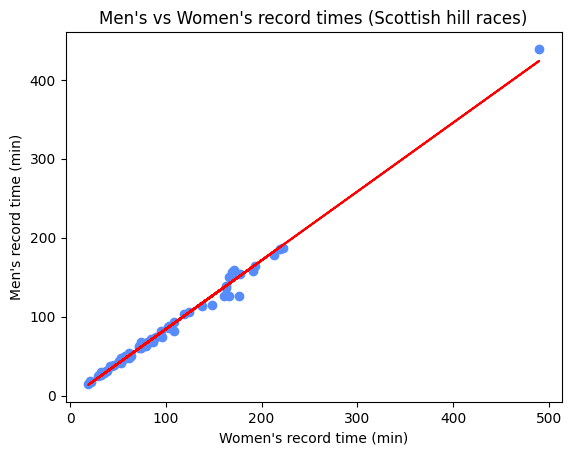

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

races = pd.read_csv("http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat", sep=r"\s+")

X = sm.add_constant(races["timeW"])
model = sm.OLS(races["timeM"], X).fit()
b0, b1 = model.params["const"], model.params["timeW"]
print("Prediction equation: timeM =", round(b0, 2), "+", round(b1, 2), "* timeW")

pred = b0 + b1 * 490.05
print("Predicted timeM at timeW = 490.05:", round(pred, 2))

plt.scatter(races["timeW"], races["timeM"])
plt.plot(races["timeW"], b0 + b1 * races["timeW"], color="red")
plt.xlabel("Women's record time (min)")
plt.ylabel("Men's record time (min)")
plt.title("Men's vs Women's record times (Scottish hill races)")
plt.show()

(b) Find and interpret the correlation.

The correlation is **1.00** (0.9959 before rounding). That is a almost perfect positive linear relationship. It makes sense because men and women are racing the same courses, so a course that takes women a long time also takes men a long time.

In [2]:
r = round(races["timeM"].corr(races["timeW"]), 2)
print("Correlation between timeM and timeW:", r)

Correlation between timeM and timeW: 1.0


(c) We could impose the natural constraint that when timeW = 0, then timeM = 0. Fit the model $E(Y_i)=\beta x_i.$ Interpret the estimated slope.

Forcing the line through the origin gives timeM = 0.85 * timeW. So the men's record time is on average about 85% of the women's record time on the same course, meaning the men are roughly 15% faster.

In [3]:
model0 = sm.OLS(races["timeM"], races["timeW"]).fit()
print("Slope (through origin):", round(model0.params["timeW"], 2))

Slope (through origin): 0.85


## Problem 6.2.

For advanced industrialized nations, the Firearms data file at the text website shows annual homicide rates (per million population) and the number of firearms (per 100 people), with data taken from Wikipedia and [smallarmssurvey.org](smallarmssurvey.org).

(a) Construct a scatterplot and highlight any observations that fall apart from the general trend.

Most of the countries sit in a cluster with relatively few firearms and low homicide rates. The **US** stands way out on its own with by far the most firearms (89 per 100 people) and a much higher homicide rate (28.3), so it is the clear outlier.

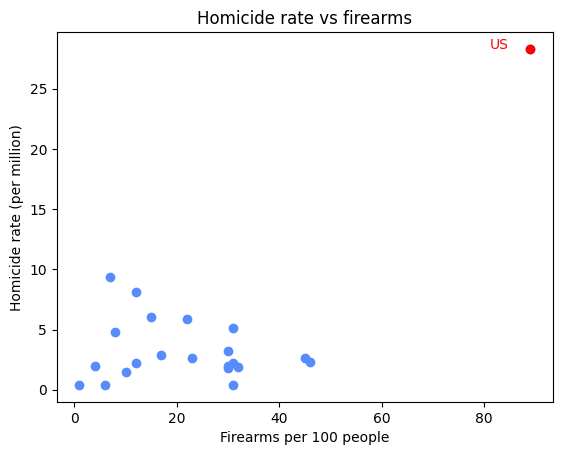

In [4]:
fire = pd.read_csv("http://stat4ds.rwth-aachen.de/data/Firearms.dat", sep=r"\s+")

plt.scatter(fire["firearms"], fire["deaths"])
us = fire[fire["Nation"] == "US"]   # highlight the outlier
plt.scatter(us["firearms"], us["deaths"], color="red")
plt.text(us["firearms"].values[0] - 8, us["deaths"].values[0], "US", color="red")
plt.xlabel("Firearms per 100 people")
plt.ylabel("Homicide rate (per million)")
plt.title("Homicide rate vs firearms")
plt.show()

(b) Find the correlation with and without the outlying observation. Why is it so different in the two cases?

With the US included the correlation is **0.63**, but once I drop the US it falls to **-0.18**. It changes so much because the US is a single extreme point that is high on both variables, so it drags the correlation up and basically creates the positive trend by itself. Without it there is almost no relationship left.

In [5]:
full = round(fire["deaths"].corr(fire["firearms"]), 2)
no_us = fire[fire["Nation"] != "US"]
without = round(no_us["deaths"].corr(no_us["firearms"]), 2)
print("Correlation with US:   ", full)
print("Correlation without US:", without)

Correlation with US:    0.63
Correlation without US: -0.18


(c) Fit the linear regression model with and without the outlying observation, and note how influential an outlier can be on the fit.

With the US the slope is +0.19 (more firearms goes with more homicides). Without the US the slope actually flips to -0.03, which is basically flat. One single observation completely changes the direction of the fitted line, which shows how influential an outlier can be.

In [6]:
Xa = sm.add_constant(fire["firearms"])
m_all = sm.OLS(fire["deaths"], Xa).fit()
Xb = sm.add_constant(no_us["firearms"])
m_no = sm.OLS(no_us["deaths"], Xb).fit()
print("With US:    deaths =", round(m_all.params["const"], 2), "+", round(m_all.params["firearms"], 2), "* firearms")
print("Without US: deaths =", round(m_no.params["const"], 2), "+", round(m_no.params["firearms"], 2), "* firearms")

With US:    deaths = -0.27 + 0.19 * firearms
Without US: deaths = 3.91 + -0.03 * firearms


## Problem 6.5.

For the `Covid19` data file at the text website:  
http://stat4ds.rwth-aachen.de/data/Covid19.dat 

(a) Construct the two scatterplots shown in Figure 6.3.

The first plot (cases vs day) curves upward and looks exponential, not a straight line. The second plot (log(cases) vs day) is almost a perfect straight line, which is what we expect when something is growing exponentially.

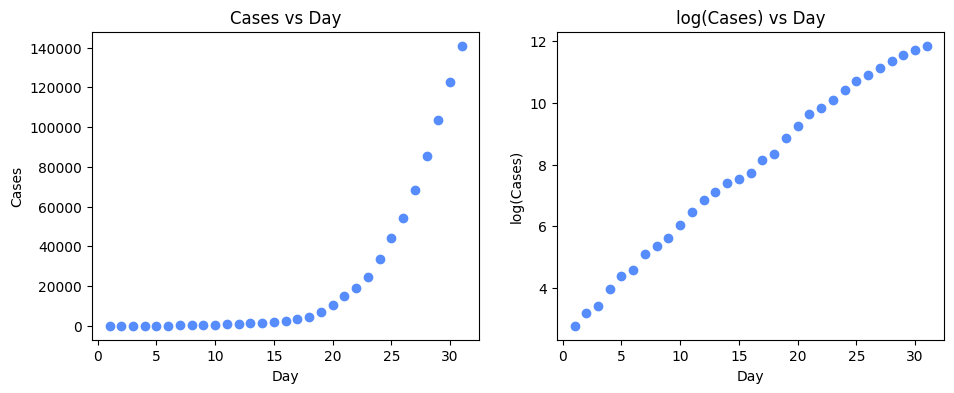

In [7]:
covid = pd.read_csv("http://stat4ds.rwth-aachen.de/data/Covid19.dat", sep=r"\s+")
covid["logcases"] = np.log(covid["cases"])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(covid["day"], covid["cases"])
ax[0].set_xlabel("Day"); ax[0].set_ylabel("Cases"); ax[0].set_title("Cases vs Day")
ax[1].scatter(covid["day"], covid["logcases"])
ax[1].set_xlabel("Day"); ax[1].set_ylabel("log(Cases)"); ax[1].set_title("log(Cases) vs Day")
plt.show()

(b) Find and interpret the correlation between time and (i) cases, (ii) log(cases).

day vs cases has a correlation of **0.79** — strong but not perfect, because the raw relationship is curved. day vs log(cases) is **1.00**, basically perfect, since taking the log straightens the exponential growth into a line.

In [8]:
print("Correlation day vs cases:     ", round(covid["day"].corr(covid["cases"]), 2))
print("Correlation day vs log(cases):", round(covid["day"].corr(covid["logcases"]), 2))

Correlation day vs cases:      0.79
Correlation day vs log(cases): 1.0


(c)  Fit the linear model for the log-transformed counts and report the prediction equation.$^{29}.$ Explain why the predicted count at day $x+1$ equals the predicted count at day $x$ multiplied by $\text{exp}(\hat\beta_1)=1.36.$

The fitted model is log(cases) = 2.84 + 0.31 * day. Going from day x to day x+1 adds 0.31 to log(cases). Adding to a log is the same as multiplying on the original scale, so the predicted count gets multiplied by exp(0.31) = **1.36** each day. In other words cases grow about 36% per day.

In [9]:
Xc = sm.add_constant(covid["day"])
logmodel = sm.OLS(covid["logcases"], Xc).fit()
b0, b1 = logmodel.params["const"], logmodel.params["day"]
print("log(cases) =", round(b0, 2), "+", round(b1, 2), "* day")
print("exp(slope) =", round(np.exp(b1), 2))

log(cases) = 2.84 + 0.31 * day
exp(slope) = 1.36


## Problem 6.8.

Refer to the example in Section 6.2.5 of the crime rate in Florida counties.

(a) Explain what it means when we say these data exhibit *Simpson’s paradox*. What could cause this change in the direction of the association between crime rate and education
when we adjust for urbanization?

Simpson's paradox here means that if you only look at crime rate vs education, higher education looks like it goes with *higher* crime (a positive association). But once we adjust for urbanization, the association flips and becomes negative. The cause is that urbanization is a confounder: cities tend to have both more educated people and more crime. So the positive link between education and crime is really urbanization driving both of them. Once you hold urbanization constant, education on its own is associated with *less* crime.

(b) Using the Florida data file, construct the scatterplot between *x* = education (HS) and *y* = income (Income), for which the correlation is 0.79. If we had data at the individual
level as well as aggregated for a county, sketch a scatterplot to show that at that level the correlation could be much weaker. So, predictions about individuals based on the
behavior of aggregate groups, known as the *ecological fallacy*, can be quite misleading.

At the county level the correlation between education and income is **0.79**, so counties with more high-school-educated people have higher median income. But this is aggregated (county-average) data. If we had individual people the correlation would probably be a lot weaker, because averaging over a whole county smooths out all the person-to-person variation (I made a rough hypothetical plot below to show this). Assuming individuals follow the same strong pattern as the county averages is the ecological fallacy.

Correlation HS vs Income: 0.79


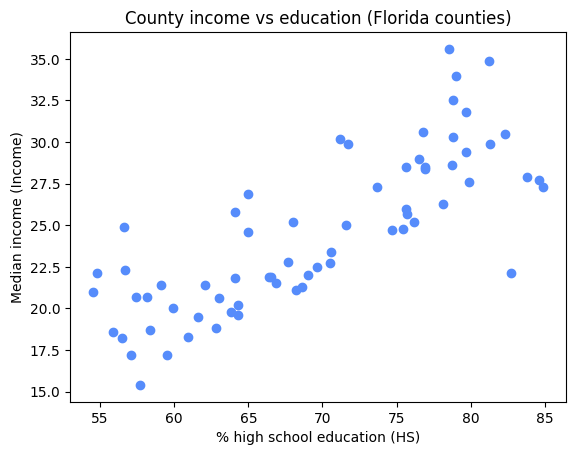

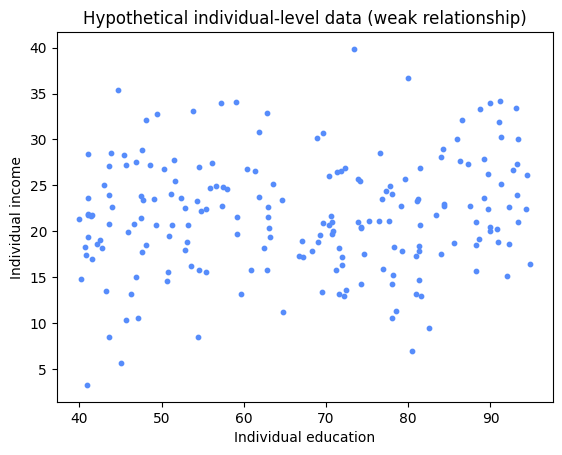

In [10]:
fl = pd.read_csv("http://stat4ds.rwth-aachen.de/data/Florida.dat", sep=r"\s+")
print("Correlation HS vs Income:", round(fl["HS"].corr(fl["Income"]), 2))

plt.scatter(fl["HS"], fl["Income"])
plt.xlabel("% high school education (HS)")
plt.ylabel("Median income (Income)")
plt.title("County income vs education (Florida counties)")
plt.show()

# rough made-up sketch of what individual-level data might look like (much weaker link)
np.random.seed(1)
hs_ind = np.random.uniform(40, 95, 200)
income_ind = 18 + 0.05 * hs_ind + np.random.normal(0, 6, 200)
plt.scatter(hs_ind, income_ind, s=10)
plt.xlabel("Individual education")
plt.ylabel("Individual income")
plt.title("Hypothetical individual-level data (weak relationship)")
plt.show()

(c) Refer to (b), in which *x* falls between 54.5 and 84.9. Is it sensible to use the least squares line to predict a county’s median income if *x* = 0? Sketch a hypothetical true relationship between *x* and *E(Y)* to show the danger of *extrapolation*, using a fitted line to predict *E(Y)* far from the observed *x* values.

No, it doesn't make sense to predict income at HS = 0. The data only covers counties where HS is between 54.5 and 84.9, and nothing is anywhere near 0. The straight line only describes the data inside that range, way out at x = 0 the true relationship could curve or flatten out completely (see the plot below). Predicting that far outside the observed data (extrapolation) is unreliable.

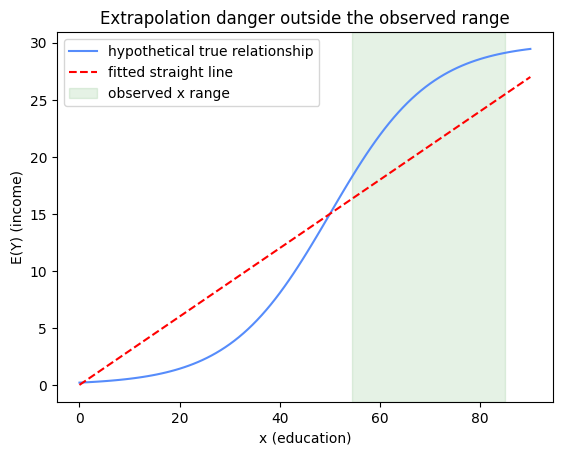

In [11]:
x = np.linspace(0, 90, 100)
true_curve = 30 / (1 + np.exp(-0.1 * (x - 50)))   # hypothetical S-shaped truth
plt.plot(x, true_curve, label="hypothetical true relationship")
plt.plot(x, 0.3 * x, "--", color="red", label="fitted straight line")
plt.axvspan(54.5, 84.9, color="green", alpha=0.1, label="observed x range")
plt.xlabel("x (education)"); plt.ylabel("E(Y) (income)")
plt.title("Extrapolation danger outside the observed range")
plt.legend()
plt.show()

## Problem 6.10.

The `Students` data file shows responses on variables summarized in Exercise 1.2.

(a) Fit the linear model using *hsgpa* = high school GPA, *tv* = weekly hours watching TV, and *sport* = weekly hours participating in sports as predictors of *cogpa* = college GPA. Report the prediction equation. What do the *P*-values suggest?

The prediction equation is cogpa = 2.82 + 0.21*hsgpa + 0.003*tv - 0.014*sport. Looking at the p-values, only **hsgpa** is significant (p = 0.04). tv (p = 0.63) and sport (p = 0.23) are not significant, so high school GPA is the only predictor that really seems to matter for college GPA here.

In [12]:
students = pd.read_csv("http://stat4ds.rwth-aachen.de/data/Students.dat", sep=r"\s+")
mod = smf.ols("cogpa ~ hsgpa + tv + sport", data=students).fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                  cogpa   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     2.179
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.101
Time:                        18:09:29   Log-Likelihood:                -18.587
No. Observations:                  60   AIC:                             45.17
Df Residuals:                      56   BIC:                             53.55
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8154      0.368      7.655      0.0

(b)  Summarize the estimated effect of *hsgpa.*

The hsgpa coefficient is **0.21**. That means for each 1-point increase in high school GPA, predicted college GPA goes up by about 0.21 points, holding TV and sport hours constant. It is the strongest predictor in the model and the only significant one.

In [13]:
print("hsgpa coefficient:", round(mod.params["hsgpa"], 2))
print("95% CI for hsgpa:", [round(v, 2) for v in mod.conf_int().loc["hsgpa"]])

hsgpa coefficient: 0.21
95% CI for hsgpa: [0.01, 0.41]


(c) Report and interpret $R^2$, adjusted $R^2$, and the multiple correlation.

R² = **0.10**, so the three predictors together only explain about 10% of the variation in college GPA. Adjusted R² is even lower at **0.06**, because it penalizes the two predictors that aren't really helping. The multiple correlation is **0.32**, which is the correlation between the actual college GPAs and the ones the model predicts. Overall this is a pretty weak model.

In [14]:
print("R-squared:           ", round(mod.rsquared, 2))
print("Adjusted R-squared:  ", round(mod.rsquared_adj, 2))
print("Multiple correlation:", round(np.sqrt(mod.rsquared), 2))

R-squared:            0.1
Adjusted R-squared:   0.06
Multiple correlation: 0.32


## Problem 6.12.

For the `UN` data file at the book’s website (see Exercise 1.24), construct a multiple regression model predicting Internet using all the other variables. Use the concept of multicollinearity to explain why adjusted $R^2$ is not dramatically greater than when GDP is the sole predictor. Compare the estimated GDP effect in the bivariate model and the multiple regression model and explain why it is so much weaker in the multiple regression model.

Using GDP by itself the adjusted R² is **0.76**, and adding all the other variables only pushes it up to **0.82** — not a dramatic jump. The reason is multicollinearity: many of the predictors carry the same information. For example GDP and HDI are correlated at 0.90, so once HDI and the others are in the model they already explain most of what GDP would have. That also explains why the GDP effect shrinks from **1.41** in the simple model to **0.44** (and not even significant) in the full model — the other correlated variables are now sharing the credit, so GDP's own coefficient gets much smaller.

In [15]:
un = pd.read_csv("http://stat4ds.rwth-aachen.de/data/UN.dat", sep=r"\s+")

# full model: every predictor except the country name and the target
predictors = [c for c in un.columns if c not in ("Nation", "Internet")]
full = smf.ols("Internet ~ " + " + ".join(predictors), data=un).fit()
bivar = smf.ols("Internet ~ GDP", data=un).fit()

print("Full model adjusted R2:", round(full.rsquared_adj, 2))
print("GDP-only adjusted R2:  ", round(bivar.rsquared_adj, 2))
print()
print("GDP coefficient (bivariate):", round(bivar.params["GDP"], 2))
print("GDP coefficient (full):     ", round(full.params["GDP"], 2))
print("Correlation GDP vs HDI:     ", round(un["GDP"].corr(un["HDI"]), 2))

Full model adjusted R2: 0.82
GDP-only adjusted R2:   0.76

GDP coefficient (bivariate): 1.41
GDP coefficient (full):      0.44
Correlation GDP vs HDI:      0.9


## Problem 7.1.

For the `Houses` data file described in Section 7.1.3, consider $Y$ = selling price, $x_1$ = tax bill (in dollars), and $x_2$ = whether the house is new.

(a) Form the scatterplot of $y$ and $x_1$. Does the normal GLM structure of constant variability in $y$ seem approproate? If not, how does it seem to be violated?

The constant-variance assumption does not look appropriate. As the tax bill gets bigger the points spread out a lot more — cheaper houses are bunched tightly together but expensive houses are scattered widely. That fanning-out shape means the variability in price grows with the mean, which breaks the normal GLM assumption of constant variability.

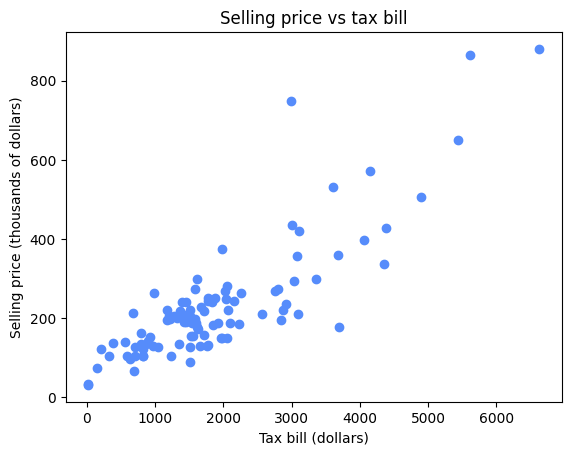

In [16]:
houses = pd.read_csv("http://stat4ds.rwth-aachen.de/data/Houses.dat", sep=r"\s+")
plt.scatter(houses["taxes"], houses["price"])
plt.xlabel("Tax bill (dollars)")
plt.ylabel("Selling price (thousands of dollars)")
plt.title("Selling price vs tax bill")
plt.show()

(b) Using the identity link function, fit the (i) normal GLM, (ii) gamma GLM. For each model, interpret the effect of $x_2$.

In the normal GLM the coefficient for new is 86.20, so a new house is predicted to sell for about 86200 more than an older house with the same tax bill. In the gamma GLM the new effect is 80.55, so about 80550 more. Both models agree that being new adds a lot to the price, the estimates are just slightly different.

In [17]:
Xh = sm.add_constant(houses[["taxes", "new"]])
normal_glm = sm.GLM(houses["price"], Xh,
                    family=sm.families.Gaussian(sm.families.links.Identity())).fit()
gamma_glm = sm.GLM(houses["price"], Xh,
                   family=sm.families.Gamma(sm.families.links.Identity())).fit()
print("Normal GLM 'new' effect:", round(normal_glm.params["new"], 2))
print("Gamma GLM 'new' effect: ", round(gamma_glm.params["new"], 2))

Normal GLM 'new' effect: 86.2
Gamma GLM 'new' effect:  80.55


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


(c) For each model, describe how the estimated variability in selling prices varies as the mean selling price varies from 100 thousand to 500 thousand dollars.

For the normal model the standard deviation is assumed constant. About 79000 whether the mean price is 100k or 500k. The gamma model is different. It assumes the standard deviation is proportional to the mean (a constant coefficient of variation of about 0.30). So at a mean of 100k the SD is about 30k, but at a mean of 500k the SD is about 148k. The gamma model lets the spread grow with price, which matches what we saw in the scatterplot.

In [18]:
print("Normal GLM constant SD (approx):", round(np.sqrt(normal_glm.scale), 2))
cv = np.sqrt(gamma_glm.scale)
print("Gamma coefficient of variation:", round(cv, 2))
for mean_price in [100, 500]:
    print("Gamma SD at mean", mean_price, "k:", round(mean_price * cv, 2))

Normal GLM constant SD (approx): 78.82
Gamma coefficient of variation: 0.3
Gamma SD at mean 100 k: 29.55
Gamma SD at mean 500 k: 147.75


(d) Which model is preferred according to AIC?

The gamma model has the lower AIC (**1104.72** vs **1160.18** for the normal model), and lower AIC is better. So the gamma GLM is preferred, which makes sense because it allows the non-constant variability we saw in part (a).

In [19]:
print("Normal GLM AIC:", round(normal_glm.aic, 2))
print("Gamma GLM AIC: ", round(gamma_glm.aic, 2))

Normal GLM AIC: 1160.18
Gamma GLM AIC:  1104.72


## Problem 7.5.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the original observation.

(a) Does the survival of the sheep seem to depend on their weight? If so, how does the weight of a sheep affect its probability of survival? Answer by fitting a generalized linear model for the survival probability.

Yes, survival clearly depends on weight. The logistic model is logit(survival) = -2.03 + 0.18*weight, and the weight effect is highly significant (p < 0.001). The positive slope means heavier sheep are more likely to survive. The odds ratio is **1.19**, so each extra kilogram multiplies the odds of surviving by about 1.19 (a 19% increase in the odds).

In [20]:
sheep = pd.read_csv("http://stat4ds.rwth-aachen.de/data/Sheep.dat", sep=r"\s+")
logit = smf.glm("survival ~ weight", data=sheep, family=sm.families.Binomial()).fit()
print(logit.summary())
print("Odds ratio per kg:", round(np.exp(logit.params["weight"]), 2))

                 Generalized Linear Model Regression Results                  
Dep. Variable:               survival   No. Observations:                 1359
Model:                            GLM   Df Residuals:                     1357
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -645.22
Date:                Mon, 15 Jun 2026   Deviance:                       1290.4
Time:                        18:09:32   Pearson chi2:                 1.44e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1294
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.0298      0.251     -8.103      0.0

(b)  For what weight values do the sheep have more than a 50% chance of survival?

Survival probability is exactly 50% at a weight of about **11.57 kg**. So sheep heavier than roughly 11.6 kg have more than a 50% chance of surviving the year, and lighter sheep have less than 50%.

In [21]:
threshold = -logit.params["Intercept"] / logit.params["weight"]
print("Weight where survival probability = 50%:", round(threshold, 2))

Weight where survival probability = 50%: 11.57


## Problem 7.9.

The `SoreThroat` data file at the book’s website contains data from from a study$^{23}$ about *Y* = whether a patient having surgery had a sore throat on waking (1 = yes, 0 = no) as a function of *D* = duration of the surgery (in minutes) and *T* = type of device used to secure the airway (1 = tracheal tube, 0 = laryngeal mask airway).

(a) Fit a GLM using both explanatory variables as main effects. Interpret effects.

The main-effects model is logit(Y) = -1.42 + 0.07*D - 1.66*T. The duration effect D is positive: each extra minute of surgery raises the odds of a sore throat by about 7% (odds ratio 1.07). The device effect T is negative: using a tracheal tube (T = 1) instead of a laryngeal mask cuts the odds of a sore throat a lot (odds ratio 0.19, about 81% lower odds). So longer surgeries are worse, and the tracheal tube is better than the mask.

In [22]:
sore = pd.read_csv("http://stat4ds.rwth-aachen.de/data/SoreThroat.dat", sep=r"\s+")
main = smf.glm("Y ~ D + T", data=sore, family=sm.families.Binomial()).fit()
print(main.summary())
print("Odds ratio D (per minute):", round(np.exp(main.params["D"]), 2))
print("Odds ratio T:", round(np.exp(main.params["T"]), 2))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   35
Model:                            GLM   Df Residuals:                       32
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15.069
Date:                Mon, 15 Jun 2026   Deviance:                       30.138
Time:                        18:09:33   Pearson chi2:                     37.0
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3677
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4173      1.095     -1.295      0.1

(b) Fit a GLM permitting interaction between the explanatory variables. Interpret the effect of *D* at each category of *T*.

With the interaction, logit(Y) = 0.05 + 0.03*D - 4.47*T + 0.07*(D*T). For the laryngeal mask (T = 0) the duration effect is 0.03 per minute, but for the tracheal tube (T = 1) it is 0.03 + 0.07 = 0.10 per minute. So duration matters more when the tracheal tube is used — sore-throat risk climbs faster with longer surgeries for the tube than for the mask.

In [23]:
inter = smf.glm("Y ~ D * T", data=sore, family=sm.families.Binomial()).fit()
print(inter.summary())
print("D effect at T=0 (mask):", round(inter.params["D"], 2))
print("D effect at T=1 (tube):", round(inter.params["D"] + inter.params["D:T"], 2))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   35
Model:                            GLM   Df Residuals:                       31
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14.161
Date:                Mon, 15 Jun 2026   Deviance:                       28.321
Time:                        18:09:33   Pearson chi2:                     28.6
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3997
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0498      1.469      0.034      0.9

## 7.10 Predicting Diabetes Using Logistic Regression

In this exercise, you will build a simple AI classification model using logistic regression to predict whether a patient has diabetes. You will use the Diabetes dataset available directly from sklearn.datasets.

### Task

Load the diabetes dataset, explore the features, and build a logistic regression model that predicts the presence of diabetes.
Then, discuss whether logistic regression is appropriate for this AI task based on what we have covered in class.

### Your Steps

1. Load the diabetes dataset from sklearn.

2. Split the data into training and test sets.

3. Fit a logistic regression model. *Hint: Scale the features if necessary.*

4. Evaluate accuracy, f1 score, precision, recall, and roc auc on the test set.

5. Write a short reflection: does logistic regression seem like a reasonable AI model for this problem? Why or why not?

### Starter Code

1. Load the diabetes dataset from sklearn

In [24]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Load the dataset
data = load_diabetes()

2. Split the data into training and test sets.

In [25]:
import numpy as np

# the diabetes target is a continuous disease-progression score, so to do a
# yes/no logistic regression I turn it into a binary label using the median
# (1 = above-median progression, 0 = at or below the median)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = (data.target > np.median(data.target)).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Class balance:", pd.Series(y).value_counts().to_dict())

Train size: (309, 10)  Test size: (133, 10)
Class balance: {1: 221, 0: 221}


3. Fit a logistic regression model. *Hint: Scale the features if necessary.*

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
print("Model fitted.")

Model fitted.


4. Evaluate accuracy, f1 score, precision, recall, and roc auc on the test set.

In [27]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 2))
print("F1 score: ", round(f1_score(y_test, y_pred), 2))
print("Precision:", round(precision_score(y_test, y_pred), 2))
print("Recall:   ", round(recall_score(y_test, y_pred), 2))
print("ROC AUC:  ", round(roc_auc_score(y_test, y_proba), 2))

Accuracy:  0.77
F1 score:  0.76
Precision: 0.75
Recall:    0.77
ROC AUC:   0.87


5. Write a short reflectmion: does logistic regression seem like a reasonable AI model for this problem? Why or why not?

**Reflection:** Logistic regression works reasonably well here. On the test set it gets about 77% accuracy, an F1 of 0.76, precision 0.75, recall 0.77, and a ROC AUC of 0.87, which is pretty good for such a simple model, and it is easy to interpret — nice for a health setting.

That said, there is a big caveat. The sklearn diabetes dataset is not actually a yes/no diabetes label — the target is a continuous disease-progression score. I had to split it at the median to force a binary outcome, so a '1' really just means 'above-median progression', not a real diagnosis. That makes the problem a bit artificial. Logistic regression also assumes the log-odds are linear in the features, which may not perfectly hold. So I'd say logistic regression is a reasonable baseline model for this kind of binary prediction, but the made-up label is its main weakness, and I would want a properly labeled dataset before trusting it for anything real.

&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;


----------------
$^{23}$ Described in “Binary Data” by D. Collett, *Encyclopedia of Biostatistics*, 2nd ed. (Wiley, 2005), pp. 439–446.

$^{29}$ Some lack of fit the last few days reflects the impact of increasing “social distancing.”